In [1]:
from ray import tune
import pandas as pd

In [2]:
from ray.tune import ExperimentAnalysis

analysis = ExperimentAnalysis("/home/jgerrits/portfolio-S3/logs/ray_flowers/train_2026-03-14_09-28-39")

df_it1 = analysis.dataframe()
print(df_it1.head())

   train_loss  train_accuracy  val_loss  val_accuracy  epoch   timestamp  \
0    2.866492        0.270588  3.120310      0.246078      6  1773482146   
1    3.070666        0.241176  3.254371      0.220588      6  1773481312   
2    3.747633        0.130392  3.767441      0.177451      6  1773477973   
3    3.473670        0.236275  3.485850      0.245098      6  1773480635   
4    3.301088        0.276471  3.402194      0.247059      6  1773480417   

  checkpoint_dir_name   done  training_iteration     trial_id  ...  \
0                None  False                   6  cd65b_00016  ...   
1                None  False                   6  cd65b_00011  ...   
2                None  False                   6  cd65b_00004  ...   
3                None  False                   6  cd65b_00012  ...   
4                None  False                   6  cd65b_00008  ...   

                                    hostname       node_ip  \
0  uos3jgerrits7.uos3-han.src.surf-hosted.nl  192.168.1.37  

In [3]:
print(
    df_it1[
        [
            "config/lr",
            "config/base_channels",
            "config/num_layers",
            "val_accuracy",
            "val_loss",
        ]
    ].sort_values("val_accuracy", ascending=False)
)

    config/lr  config/base_channels  config/num_layers  val_accuracy  val_loss
16     0.0003                    64                  4      0.277451  3.135641
15     0.0003                   128                  4      0.271569  3.017887
4      0.0003                   128                  3      0.247059  3.402194
0      0.0010                    64                  4      0.246078  3.120310
3      0.0003                    32                  4      0.245098  3.485850
9      0.0010                    64                  3      0.231373  3.365548
10     0.0010                    32                  4      0.221569  3.237981
1      0.0010                   128                  3      0.220588  3.254371
8      0.0003                    64                  3      0.219608  3.708605
12     0.0010                   128                  4      0.211765  3.302815
11     0.0010                    32                  3      0.197059  3.663970
6      0.0010                   128                 

# Heatmap

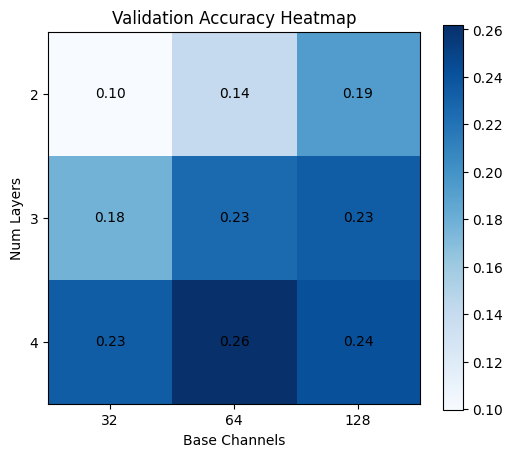

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df_it1.pivot_table(
    values="val_accuracy",
    index="config/num_layers",
    columns="config/base_channels"
)

plt.figure(figsize=(6,5))
plt.imshow(pivot, cmap="Blues")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        value = pivot.iloc[i, j]
        plt.text(j, i, f"{value:.2f}",
                 ha="center",
                 va="center",
                 color="black")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("Base Channels")
plt.ylabel("Num Layers")

plt.title("Validation Accuracy Heatmap")

plt.colorbar()

plt.show()